# Agent-State Separability in the Teacher Model (Qwen3-32B)

reason–act–observe trajectory에서 **act**(코드 블롭 안에서 호출되는 행동)를 몇 개의 **agent-state**로
나눌 수 있는지, 그리고 그 state들이 **teacher 모델(Qwen3-32B)의 내부 표현(hidden states)** 에서
**PCA**와 **linear probe**로 선형 분리되는지를 시각적으로 확인하는 노트북입니다.

**파이프라인**
1. teacher trajectory 로그(`logs/qa_results/.../*_type=agent_steps=5.jsonl`)를 파싱
2. 각 `ActionStep`의 act 코드를 규칙 기반으로 agent-state 라벨링
   (`retrieve / symbolic_math / numeric_compute / finalize / compute / inspect`)
3. 각 act를 **그 시점까지의 context와 함께** Qwen3-32B에 forward → act 토큰 span을 mean-pooling 한 layer별 hidden 표현 추출
4. **PCA** 2D 시각화 + **layer별 linear probe(LogisticRegression)** 정확도 곡선 + confusion matrix

> 참고: Qwen3-32B teacher 로그는 math 도메인만 존재합니다. `retrieve` state(QA)를 포함시키려면
> 학생(QA) 로그의 act 텍스트를 **teacher 모델에 forward 하여 표현만** 뽑습니다(생성이 아니라 표현 probing).
> 이는 "teacher가 각 act 유형을 어떻게 표현하는가"를 보는 것이며, 셀의 `INCLUDE_QA` 플래그로 끌 수 있습니다.

## Section 1 · Setup & Config

In [1]:
import sys, os, json, ast, re, gc, warnings, logging
from pathlib import Path
from collections import Counter, defaultdict
os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"

import numpy as np
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING)

def _find_root() -> Path:
    p = Path(".").resolve()
    for _ in range(6):
        if (p / "logs" / "qa_results").exists():
            return p
        p = p.parent
    return Path("/workspace/Agent-Distillation")

ROOT = _find_root()
print("Project root:", ROOT)

# ── 설정 ────────────────────────────────────────────────────────────────────
MODEL_NAME   = "Qwen/Qwen3-32B"          # teacher
DTYPE        = torch.bfloat16
DEVICE_MAP   = "auto"                     # 8x A40 분산 로드

INCLUDE_QA   = True       # QA(retrieve) act 텍스트를 teacher에 forward 하여 포함할지
MAX_PER_STATE = 120       # state당 최대 표본 수 (compute 비용 제어)
MAX_LEN       = 2048      # context 토큰 좌측 절단 한도
SEED          = 42

# 분석에 사용할 agent-state (그 외는 'other'로 제외)
TARGET_STATES = ["retrieve", "symbolic_math", "numeric_compute", "finalize", "compute", "inspect"]

# 어떤 layer를 추출/분석할지 (Qwen3-32B = 64 layer → hidden_states len 65)
LAYERS = list(range(0, 65, 2))           # 0,2,...,64

OUT_DIR = ROOT / "outputs" / "agent_state_probe"
OUT_DIR.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)

print("device count:", torch.cuda.device_count(), "| cuda:", torch.cuda.is_available())
print("layers to extract:", LAYERS)

Project root: /workspace/Agent-Distillation
device count: 2 | cuda: True
layers to extract: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64]


## Section 2 · 로그 파싱 + act → agent-state 라벨링

로그 일부 라인이 Python `repr` 문자열로 **이중 인코딩**되어 있어 `ast.literal_eval` fallback이 필요합니다.
각 trajectory를 메시지 순서대로 재구성하여, 모든 `assistant`(=Thought+Code = reason+act) 메시지마다
하나의 act 표본을 만들고, 코드 내용으로 state를 라벨링합니다. 표현 추출용 입력은
`해당 act까지의 context(prefix) + act 텍스트`이고, pooling 대상은 act 토큰 span 입니다.

In [2]:
# ── teacher / (선택)학생 로그 경로 ────────────────────────────────────────────
TEACHER_FILES = [
    ROOT / "logs/qa_results/vllm/Qwen_Qwen3-32B/math_1000_20250414_train/Qwen3-32B_temp=0.0_seed=42_type=agent_steps=5.jsonl",
    ROOT / "logs/qa_results/vllm/Qwen_Qwen3-32B/math_medium_1000_20250430_train/Qwen3-32B_temp=0.0_seed=42_type=agent_steps=5.jsonl",
]
QA_FILES = [
    ROOT / "logs/qa_results/vllm/Qwen_Qwen2.5-1.5B-Instruct/hotpotqa_500_20250422_test/Qwen2.5-1.5B-Instruct_temp=0.0_seed=42_type=agent_steps=5.jsonl",
    ROOT / "logs/qa_results/vllm/Qwen_Qwen2.5-1.5B-Instruct/musique_500_20250504_test/Qwen2.5-1.5B-Instruct_temp=0.0_seed=42_type=agent_steps=5.jsonl",
]

def load_jsonl(f):
    rows = []
    for line in open(f):
        line = line.strip()
        if not line:
            continue
        try:
            d = json.loads(line)
        except Exception:
            continue
        if isinstance(d, str):                       # 이중 인코딩 복구
            try:    d = ast.literal_eval(d)
            except Exception:
                try:    d = json.loads(d)
                except Exception: continue
        if isinstance(d, dict):
            rows.append(d)
    return rows

def get_messages(d):
    ld = d.get("log_data")
    if isinstance(ld, str):
        try:    ld = ast.literal_eval(ld)
        except Exception:
            try:    ld = json.loads(ld)
            except Exception: return []
    return ld.get("messages", []) if isinstance(ld, dict) else []

def role_of(m):  return str(m.get("role")).split(".")[-1].lower().replace("-", "_")
def text_of(m):
    c = m.get("content")
    if isinstance(c, list):
        return " ".join(x.get("text", "") for x in c if isinstance(x, dict))
    return str(c)

def code_of(assistant_text):
    m = re.search(r"```py(.*?)```", assistant_text, re.S) or re.search(r"Code:\s*(.*)$", assistant_text, re.S)
    return m.group(1) if m else assistant_text

def label_state(code):
    """act 코드를 단일 agent-state로 라벨 (우선순위 적용)."""
    c = code.lower()
    if re.search(r"\b(retriever|web_search|wiki|document_qa|image_search|visit_webpage)\b|\bsearch\(", c):
        return "retrieve"
    if re.search(r"sympy|symbols\(|\bsolve\(|\bEq\(|simplify|integrate|\bdiff\(|expand\(|factor\(", code):
        return "symbolic_math"
    if re.search(r"\bnp\.|numpy|\bmath\.|factorial|comb\(|sqrt\(|\.evalf", code):
        return "numeric_compute"
    flat = re.sub(r"\s", "", code)
    if re.match(r"^final_answer\(.*\)$", flat) or (re.search(r"final_answer\(", c) and not re.search(r"\bfor\b|\bwhile\b|\bdef\b|=", code)):
        return "finalize"
    if re.search(r"\bfor\b|\bwhile\b|\bdef\b|range\(|append\(", code):
        return "compute"
    if re.search(r"\bprint\(", c):
        return "inspect"
    return "other"

def extract_acts(files, domain):
    """각 act → dict(prefix, act, state, domain)."""
    out = []
    for f in files:
        if not Path(f).exists():
            print("  [skip] not found:", f); continue
        for d in load_jsonl(f):
            msgs = get_messages(d)
            prefix = ""
            for m in msgs:
                if not isinstance(m, dict):
                    continue
                r = role_of(m)
                if r == "tool_call":            # 구조화 중복 → 표현 입력에서 제외
                    continue
                t = text_of(m)
                if r == "assistant":
                    st = label_state(code_of(t))
                    out.append({"prefix": prefix, "act": t, "state": st, "domain": domain})
                    prefix = prefix + "\n" + t
                else:                            # system / user / tool_response(observation)
                    prefix = prefix + ("\n" + t if prefix else t)
    return out

acts = extract_acts(TEACHER_FILES, "math")
if INCLUDE_QA:
    acts += extract_acts(QA_FILES, "qa")

print("총 act 표본:", len(acts))
print("state 분포 :", dict(Counter(a["state"] for a in acts).most_common()))

총 act 표본: 7180
state 분포 : {'retrieve': 4382, 'symbolic_math': 798, 'compute': 628, 'other': 407, 'numeric_compute': 377, 'finalize': 330, 'inspect': 258}


In [3]:
# ── TARGET_STATES만 남기고 state당 MAX_PER_STATE 로 균형 샘플링 ────────────────
by_state = defaultdict(list)
for a in acts:
    if a["state"] in TARGET_STATES:
        by_state[a["state"]].append(a)

samples = []
for st in TARGET_STATES:
    pool = by_state.get(st, [])
    if not pool:
        print(f"  [warn] state '{st}' 표본 없음 → 제외"); continue
    idx = rng.permutation(len(pool))[:MAX_PER_STATE]
    samples += [pool[i] for i in idx]

rng.shuffle(samples)
STATES = [s for s in TARGET_STATES if by_state.get(s)]
print("최종 표본:", len(samples))
print("state별 :", dict(Counter(s["state"] for s in samples).most_common()))
print("domain별:", dict(Counter(s["domain"] for s in samples).most_common()))

최종 표본: 720
state별 : {'numeric_compute': 120, 'inspect': 120, 'retrieve': 120, 'finalize': 120, 'compute': 120, 'symbolic_math': 120}
domain별: {'math': 465, 'qa': 255}


## Section 3 · Teacher 모델 로드 (Qwen3-32B, multi-GPU)

In [4]:
from transformers import AutoModelForCausalLM, AutoTokenizer

print("Loading", MODEL_NAME, "...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=DTYPE,
    device_map=DEVICE_MAP,
    trust_remote_code=True,
    output_hidden_states=True,
)
model.eval()

EMB_DEVICE = model.get_input_embeddings().weight.device
N_LAYERS = model.config.num_hidden_layers
HID = model.config.hidden_size
print(f"layers={N_LAYERS}  hidden={HID}  emb_device={EMB_DEVICE}")

Loading Qwen/Qwen3-32B ...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading weights: 100%|██████████| 707/707 [00:08<00:00, 86.83it/s] 


layers=64  hidden=5120  emb_device=cuda:0


## Section 4 · Hidden representation 추출

각 표본에 대해 `prefix + act`를 토큰화하고(좌측 절단), **act 토큰 구간만 mean-pooling** 하여
`LAYERS`별 표현 벡터를 만듭니다. 결과는 `outputs/agent_state_probe/`에 캐시되어 재실행 시 즉시 로드됩니다.

In [5]:
CACHE = OUT_DIR / f"reps_{'with' if INCLUDE_QA else 'no'}qa_n{MAX_PER_STATE}.npz"

@torch.no_grad()
def rep_of(prefix, act):
    pre_ids  = tokenizer(prefix, add_special_tokens=True).input_ids if prefix else [tokenizer.bos_token_id or tokenizer.eos_token_id]
    full_ids = tokenizer(prefix + "\n" + act, add_special_tokens=True).input_ids
    start = len(pre_ids)
    orig = len(full_ids)
    if orig > MAX_LEN:                                   # 좌측 절단 (act는 꼬리에 보존)
        full_ids = full_ids[-MAX_LEN:]
        start = max(0, start - (orig - MAX_LEN))
    if start >= len(full_ids):                           # act가 전부 잘리면 마지막 토큰
        start = len(full_ids) - 1
    ids = torch.tensor([full_ids], device=EMB_DEVICE)
    out = model(input_ids=ids, output_hidden_states=True, use_cache=False)
    hs = out.hidden_states                               # tuple len N_LAYERS+1
    vecs = {}
    for L in LAYERS:
        span = hs[L][0, start:, :]                       # act 토큰 구간
        vecs[L] = span.mean(0).float().cpu().numpy()
    return vecs

if CACHE.exists():
    data = np.load(CACHE, allow_pickle=True)
    X = {int(k.split("_")[1]): data[k] for k in data.files if k.startswith("X_")}
    y = data["y"]; dom = data["dom"]
    print("loaded cache:", CACHE, "| X layer0 shape:", X[LAYERS[0]].shape)
else:
    try:
        from tqdm.auto import tqdm
    except Exception:
        def tqdm(x, **k): return x
    buf = {L: [] for L in LAYERS}
    y, dom = [], []
    for s in tqdm(samples, desc="extract"):
        v = rep_of(s["prefix"], s["act"])
        for L in LAYERS:
            buf[L].append(v[L])
        y.append(s["state"]); dom.append(s["domain"])
    X = {L: np.stack(buf[L]) for L in LAYERS}
    y = np.array(y); dom = np.array(dom)
    np.savez_compressed(CACHE, y=y, dom=dom, **{f"X_{L}": X[L] for L in LAYERS})
    print("saved cache:", CACHE)

print("표본 수:", len(y), "| 표현 차원:", X[LAYERS[0]].shape[1])

extract: 100%|██████████| 720/720 [17:48<00:00,  1.48s/it]


saved cache: /workspace/Agent-Distillation/outputs/agent_state_probe/reps_withqa_n120.npz
표본 수: 720 | 표현 차원: 5120


## Section 5 · PCA 시각화

선택한 layer에서 표현을 표준화 후 2D PCA로 투영하여 state별 색으로 산점도를 그립니다.
여러 layer를 한눈에 비교할 수 있도록 grid도 함께 그립니다.

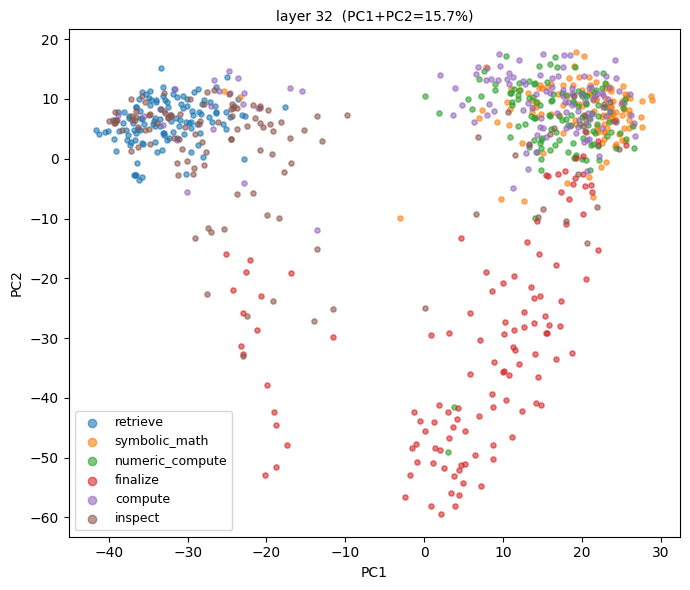

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import matplotlib
CMAP = {s: c for s, c in zip(STATES, matplotlib.cm.tab10.colors)}

def pca_scatter(ax, L):
    Z = StandardScaler().fit_transform(X[L])
    p = PCA(n_components=2, random_state=SEED).fit(Z)
    P = p.transform(Z)
    for s in STATES:
        m = (y == s)
        ax.scatter(P[m, 0], P[m, 1], s=14, alpha=0.6, color=CMAP[s], label=s)
    ev = p.explained_variance_ratio_
    ax.set_title(f"layer {L}  (PC1+PC2={ev.sum()*100:.1f}%)", fontsize=10)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")

# 단일 layer (중간 layer) 크게
MID = LAYERS[len(LAYERS)//2]
fig, ax = plt.subplots(figsize=(7, 6))
pca_scatter(ax, MID)
ax.legend(markerscale=1.6, fontsize=9, loc="best")
plt.tight_layout(); plt.show()

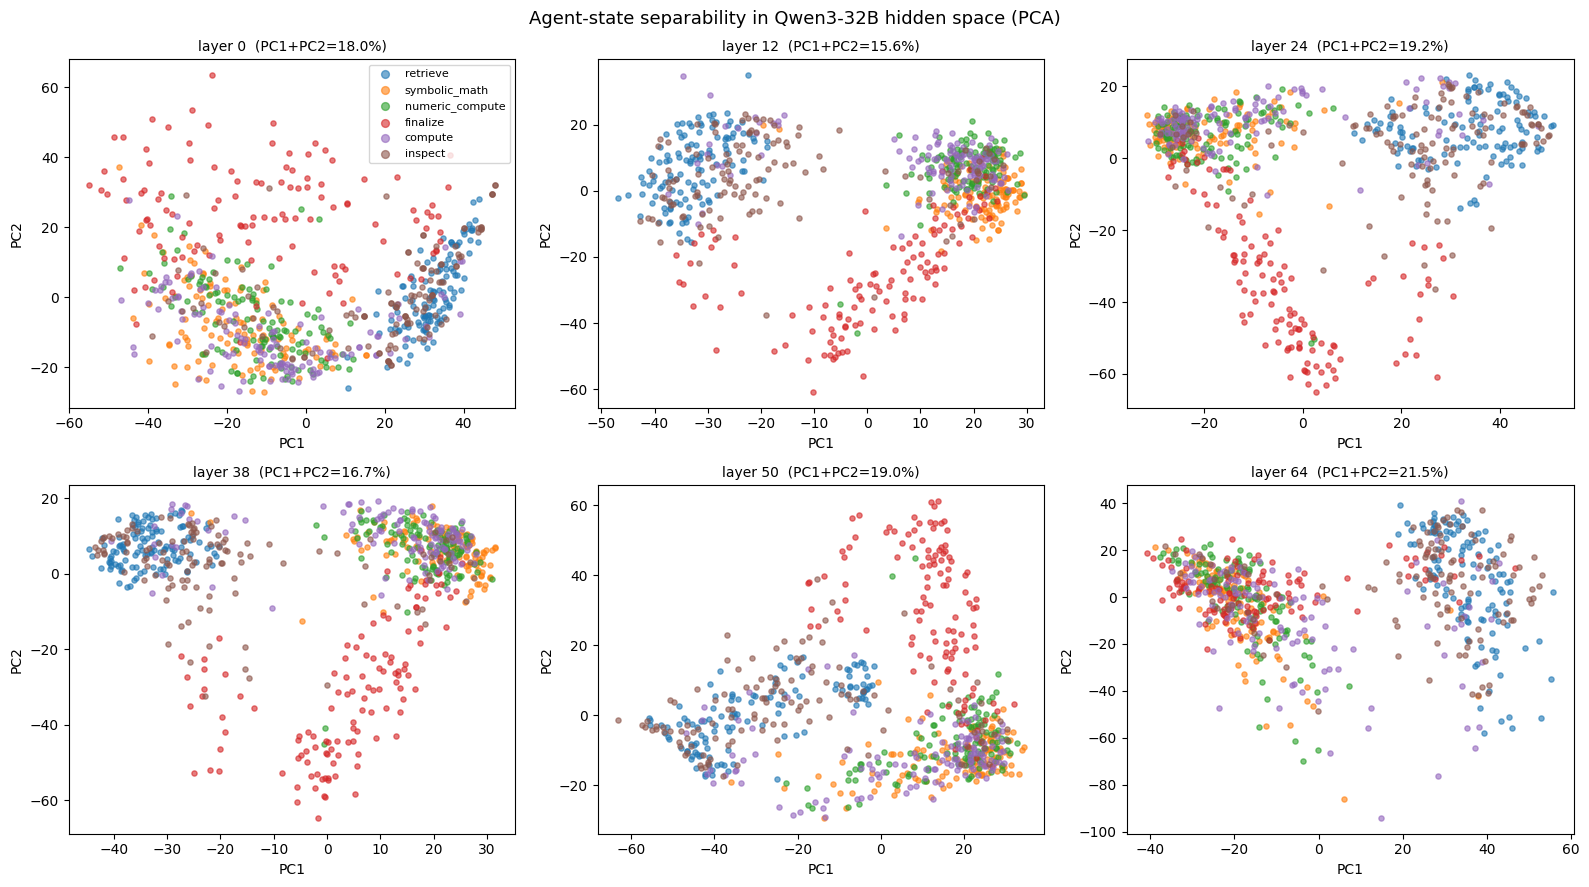

In [7]:
# 여러 layer grid 비교
grid = [LAYERS[i] for i in np.linspace(0, len(LAYERS)-1, 6).astype(int)]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, L in zip(axes.flat, grid):
    pca_scatter(ax, L)
axes.flat[0].legend(markerscale=1.5, fontsize=8, loc="best")
plt.suptitle("Agent-state separability in Qwen3-32B hidden space (PCA)", fontsize=13)
plt.tight_layout(); plt.show()

## Section 6 · Linear probe (LogisticRegression)

각 layer에서 표현이 agent-state를 **선형적으로** 얼마나 잘 구분하는지 측정합니다.
- stratified train/test split + 표준화 + multinomial LogisticRegression
- layer별 test accuracy & macro-F1 곡선 → "어느 깊이에서 state가 선형 분리되는가"
- 최적 layer의 confusion matrix

best layer = 12  acc=0.907  (chance=0.167, majority~0.167)


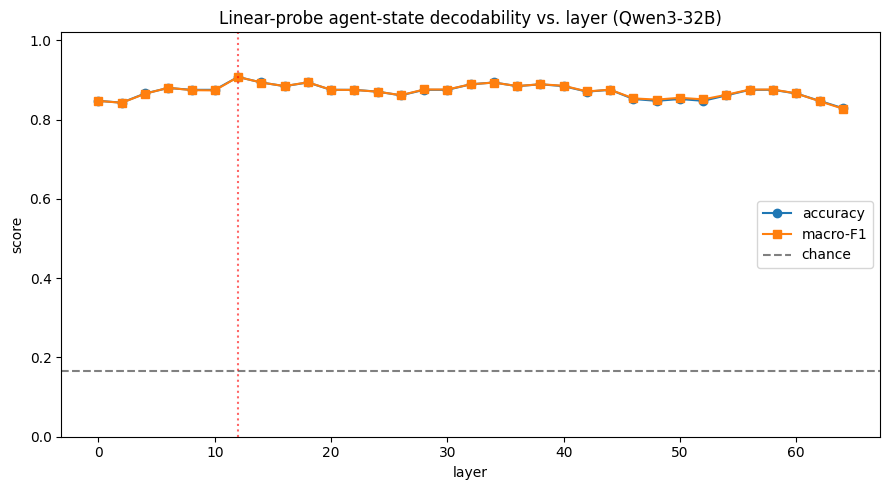

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.pipeline import make_pipeline

idx = np.arange(len(y))
tr, te = train_test_split(idx, test_size=0.3, random_state=SEED, stratify=y)

def probe(L):
    # sklearn>=1.7 은 multiclass 시 자동 multinomial (multi_class 인자 제거됨)
    clf = make_pipeline(StandardScaler(),
                        LogisticRegression(max_iter=2000, C=1.0))
    clf.fit(X[L][tr], y[tr])
    pred = clf.predict(X[L][te])
    return accuracy_score(y[te], pred), f1_score(y[te], pred, average="macro"), clf, pred

accs, f1s = [], []
for L in LAYERS:
    a, f, _, _ = probe(L)
    accs.append(a); f1s.append(f)

maj = Counter(y[tr]).most_common(1)[0][1] / len(tr)   # majority baseline (대략)
best_L = LAYERS[int(np.argmax(accs))]
print(f"best layer = {best_L}  acc={max(accs):.3f}  (chance={1/len(STATES):.3f}, majority~{Counter(y[te]).most_common(1)[0][1]/len(te):.3f})")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(LAYERS, accs, "-o", label="accuracy", color="C0")
ax.plot(LAYERS, f1s, "-s", label="macro-F1", color="C1")
ax.axhline(1/len(STATES), ls="--", c="gray", label="chance")
ax.axvline(best_L, ls=":", c="red", alpha=0.6)
ax.set_xlabel("layer"); ax.set_ylabel("score"); ax.set_ylim(0, 1.02)
ax.set_title("Linear-probe agent-state decodability vs. layer (Qwen3-32B)")
ax.legend(); plt.tight_layout(); plt.show()

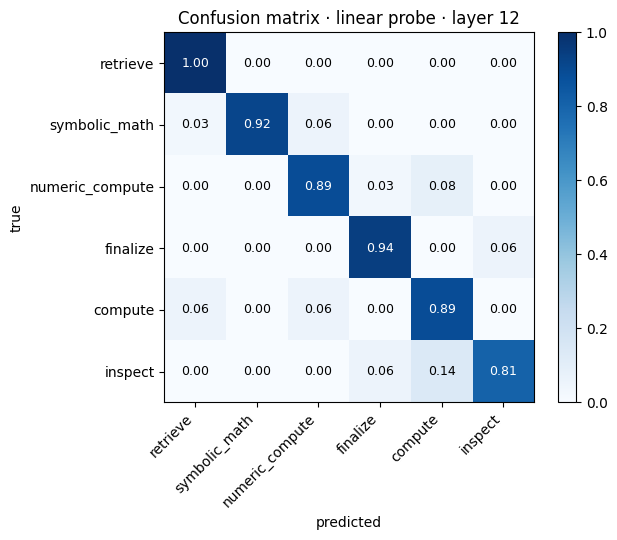

                 precision    recall  f1-score   support

       retrieve      0.923     1.000     0.960        36
  symbolic_math      1.000     0.917     0.957        36
numeric_compute      0.889     0.889     0.889        36
       finalize      0.919     0.944     0.932        36
        compute      0.800     0.889     0.842        36
        inspect      0.935     0.806     0.866        36

       accuracy                          0.907       216
      macro avg      0.911     0.907     0.907       216
   weighted avg      0.911     0.907     0.907       216



In [9]:
# 최적 layer confusion matrix + 리포트
_, _, clf, pred = probe(best_L)
cm = confusion_matrix(y[te], pred, labels=STATES)
cmn = cm / cm.sum(1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(STATES))); ax.set_xticklabels(STATES, rotation=45, ha="right")
ax.set_yticks(range(len(STATES))); ax.set_yticklabels(STATES)
for i in range(len(STATES)):
    for j in range(len(STATES)):
        ax.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center",
                color="white" if cmn[i,j] > 0.5 else "black", fontsize=9)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"Confusion matrix · linear probe · layer {best_L}")
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

print(classification_report(y[te], pred, labels=STATES, digits=3))

## Section 7 · 결론 / 메모

- **PCA**: teacher(Qwen3-32B) hidden space에서 agent-state들이 (특히 중후반 layer에서) 군집으로 갈라지는지 시각 확인.
- **Linear probe**: layer별 정확도 곡선으로 state가 *선형적으로* 디코딩 가능한 깊이를 정량화. chance/majority 대비 큰 차이면 "act는 서로 다른 agent-state로 잘 분리된다"는 근거.

**조정 포인트**
- `TARGET_STATES` / `MAX_PER_STATE` 로 분석 대상 state·표본 수 조절
- `INCLUDE_QA=False` → math-only teacher act만으로 (순수 teacher-생성 분포) 분석
- pooling을 last-token으로 바꾸려면 `rep_of`에서 `span.mean(0)` → `span[-1]`
- 더 강한 분리 지표가 필요하면 LDA / silhouette score / k-NN probe 추가 가능

In [10]:
# 리소스 정리
del model
gc.collect(); torch.cuda.empty_cache()
print("freed.")

freed.
